# 05_featuring — Price Prediction Feature Engineering

Builds directly on `03_Post_EDA.ipynb`. Inputs are the two files it saved:

- `../data/processed/cars_listings_clean.csv` — cleaned listings, includes `matched_review_model`
- `../data/processed/cars_reviews_clean.csv` — cleaned Edmunds expert reviews

This notebook:

1. Enriches listings with expert-review features (for the ~53.5% that have a `matched_review_model`)
2. Engineers numeric, engine-spec, and categorical features from the raw listing fields
3. Splits train/test **before** any target/frequency encoding, to avoid leakage
4. Fits encoders/imputers on train only, saves a reusable preprocessing pipeline
5. Saves final model-ready train/test feature sets
6. Trains a quick baseline (Linear Regression + Random Forest) as a sanity check — not the final model, just confirmation the features carry signal

**Output artifacts:**
- `../data/processed/cars_features_train.csv`
- `../data/processed/cars_features_test.csv`
- `../models/preprocessing_pipeline.joblib`


In [1]:
import os
import re
import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 40)
RANDOM_STATE = 42


## Part A — Load the cleaned data from 03_Post_EDA

In [2]:
df = pd.read_csv("../data/processed/cars_listings_clean.csv", low_memory=False)
reviews = pd.read_csv("../data/processed/cars_reviews_clean.csv", low_memory=False)

print("Listings:", df.shape)
print("Reviews:", reviews.shape)
df.head(3)


Listings: (749842, 28)
Reviews: (3342, 26)


,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price,age,transmission_type,drivetrain_type,fuel_type_clean,manufacturer_clean,model_clean,price_log,matched_review_model
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0,13,Automatic,FWD,Gasoline,acura,ilx hybrid 1.5l,9.546027,ilx
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0,13,CVT,FWD,Hybrid,acura,ilx hybrid 1.5l,9.797905,ilx
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0,13,CVT,FWD,Hybrid,acura,ilx hybrid 1.5l,9.741027,ilx


## Part B — Enrich listings with expert-review features

`matched_review_model` (from 03_Post_EDA) tells us *which* review base-model a listing
matches on `(manufacturer_clean, model_base)` — but reviews are also keyed by
`manufacturing year`, and the match step never pinned an exact year. A listing's
year won't always have its own review row for that model, so for each match we take
the **closest available review year** for that brand + base model, rather than
requiring an exact year match (which would throw away most of the 53.5%).

Rows with `matched_review_model` null are left unenriched — `has_review_match` flags this
explicitly so the model can learn from it, and so we can later compare the price model
with vs. without review features per the "Next steps" note in 03_Post_EDA.

In [3]:
# --- Parse review fields into usable numeric features -----------------------

def parse_rating(x):
    """'4.3 out of 5 stars' -> 4.3. Already-numeric or unparseable -> NaN."""
    if pd.isna(x):
        return np.nan
    m = re.search(r'([\d.]+)', str(x))
    return float(m.group(1)) if m else np.nan

def extract_numeric(series):
    """Pull the first number out of a possibly-string column (handles thousands separators
    and unit suffixes like '182 hp', '3,086 lbs', '182.3 in'). Leaves already-numeric
    columns untouched."""
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    return (series.astype(str)
            .str.replace(',', '', regex=False)
            .str.extract(r'([-+]?\d*\.?\d+)')[0]
            .astype(float))

def count_list_items(x):
    """strengths/weaknesses are stored as string-encoded Python lists, e.g.
    \"['Punchy V6', 'Comfortable ride']\". Count items; treat parse failures as 0."""
    if pd.isna(x):
        return 0
    try:
        parsed = ast.literal_eval(x)
        return len(parsed) if isinstance(parsed, list) else 0
    except (ValueError, SyntaxError):
        return 0

reviews_feat = reviews.copy()

# `cars_reviews_clean.csv` was saved by 03_Post_EDA BEFORE it computed `model_base`
# (that happens two cells later, only in-memory, to build the match against listings).
# So the column never made it to disk here — recompute it with the same logic.
def strip_brand_prefix(row):
    b, m = row['brand_clean'], row['model_clean']
    if pd.isna(m):
        return None
    m = str(m)
    if isinstance(b, str) and m.startswith(b + ' '):
        m = m[len(b) + 1:]
    return m.replace('-', ' ').strip()

reviews_feat['model_base'] = reviews_feat.apply(strip_brand_prefix, axis=1)

reviews_feat['review_rating_num'] = reviews_feat['rating'].apply(parse_rating)
reviews_feat['review_strengths_count'] = reviews_feat['strengths'].apply(count_list_items)
reviews_feat['review_weaknesses_count'] = reviews_feat['weaknesses'].apply(count_list_items)

for col, new_col in [
    ('horsepower', 'review_horsepower'),
    ('torque', 'review_torque'),
    ('curb weight', 'review_curb_weight'),
    ('length', 'review_length'),
    ('height', 'review_height'),
    ('overall width with mirrors', 'review_width'),
    ('cargo capacity, all seats In place', 'review_cargo_capacity'),
    ('word count for full description', 'review_desc_word_count'),
]:
    if col in reviews_feat.columns:
        reviews_feat[new_col] = extract_numeric(reviews_feat[col])

review_feature_cols = [c for c in reviews_feat.columns if c.startswith('review_')]

reviews_lookup = reviews_feat[['brand_clean', 'model_base', 'manufacturing year'] + review_feature_cols].copy()
reviews_lookup = reviews_lookup.dropna(subset=['brand_clean', 'model_base'])
reviews_lookup.head(3)


,brand_clean,model_base,manufacturing year,review_rating_num,review_strengths_count,review_weaknesses_count,review_horsepower,review_torque,review_curb_weight,review_length,review_height,review_width,review_cargo_capacity,review_desc_word_count
0,jeep,wrangler,1998,4.3,1,1,120.0,140.0,3045.0,147.7,69.6,NaN,11.1,427.0
1,toyota,4runner,2005,4.8,1,1,245.0,282.0,4045.0,189.0,68.5,NaN,36.6,110.0
2,toyota,tundra,2002,4.7,1,1,190.0,220.0,3795.0,217.5,70.5,NaN,NaN,534.0


In [4]:
# --- Nearest-year join, per (brand, base model) group ------------------------
# pd.merge_asof needs both sides sorted by the "on" key within each group, so we
# run it group-by-group over the (brand, model_base) pairs that actually appear
# in the listings' matched_review_model.

def nearest_year_join(listings_df, reviews_df):
    listings_df = listings_df.reset_index().rename(columns={'index': '_orig_idx'})
    matched = listings_df.dropna(subset=['matched_review_model']).copy()
    unmatched = listings_df[listings_df['matched_review_model'].isna()].copy()

    merged_parts = []
    group_cols = ['manufacturer_clean', 'matched_review_model']
    for (brand, model_base), grp in matched.groupby(group_cols):
        candidates = reviews_df[(reviews_df['brand_clean'] == brand) &
                                 (reviews_df['model_base'] == model_base)]
        if candidates.empty:
            grp_out = grp.copy()
            for c in review_feature_cols:
                grp_out[c] = np.nan
            merged_parts.append(grp_out)
            continue

        grp_sorted = grp.sort_values('year')
        cand_sorted = candidates.sort_values('manufacturing year')
        joined = pd.merge_asof(
            grp_sorted, cand_sorted[['manufacturing year'] + review_feature_cols],
            left_on='year', right_on='manufacturing year', direction='nearest'
        )
        merged_parts.append(joined)

    for c in review_feature_cols:
        unmatched[c] = np.nan

    result = pd.concat(merged_parts + [unmatched], ignore_index=True)
    result = result.set_index('_orig_idx').sort_index()
    result.index.name = None
    return result

df = nearest_year_join(df, reviews_lookup)
df['has_review_match'] = df['matched_review_model'].notna()

print("Enriched shape:", df.shape)
print("Rows with review features filled in:", df['review_rating_num'].notna().sum())
df[['manufacturer', 'model', 'matched_review_model', 'has_review_match', 'review_rating_num']].head(8)


Enriched shape: (749842, 41)
Rows with review features filled in: 379912


,manufacturer,model,matched_review_model,has_review_match,review_rating_num
0,Acura,ILX Hybrid 1.5L,ilx,True,4.8
1,Acura,ILX Hybrid 1.5L,ilx,True,4.8
2,Acura,ILX Hybrid 1.5L,ilx,True,4.8
3,Acura,ILX Hybrid 1.5L,ilx,True,4.8
4,Acura,ILX Hybrid 1.5L,ilx,True,4.8
5,Acura,ILX Hybrid 1.5L,ilx,True,4.8
6,Acura,ILX Hybrid 1.5L,ilx,True,4.8
7,Acura,ILX Hybrid 1.5L,ilx,True,4.7


## Part C — Numeric feature engineering

Straightforward, row-wise transforms — safe to do before the train/test split since
none of these look across rows.

In [5]:
# Mileage / age derived features
df['mileage_per_year'] = df['mileage'] / df['age'].replace(0, 1)
df['mileage_log'] = np.log1p(df['mileage'])

# mpg comes in as e.g. "39-38" (city-highway) or similar hyphenated ranges — split
# and average rather than dropping the column.
def parse_mpg(x):
    if pd.isna(x):
        return np.nan, np.nan
    parts = re.findall(r'\d+', str(x))
    if len(parts) >= 2:
        return float(parts[0]), float(parts[1])
    if len(parts) == 1:
        return float(parts[0]), float(parts[0])
    return np.nan, np.nan

mpg_parsed = df['mpg'].apply(parse_mpg)
df['mpg_a'] = mpg_parsed.apply(lambda t: t[0])
df['mpg_b'] = mpg_parsed.apply(lambda t: t[1])
df['mpg_avg'] = df[['mpg_a', 'mpg_b']].mean(axis=1)
df['mpg_city'] = df[['mpg_a', 'mpg_b']].min(axis=1)
df['mpg_highway'] = df[['mpg_a', 'mpg_b']].max(axis=1)

# Engine spec extraction from free-text `engine` field.
# Note: [\d.]+ (bracket class) matches digit-OR-literal-dot, so it can match a bare
# "." with zero actual digits when the text has an unrelated ". L" nearby.
# Require at least one digit, and use pd.to_numeric(errors='coerce') as a safety net
# so any leftover bad match becomes NaN instead of crashing the whole cell.
disp_extracted = df['engine'].str.extract(r'(\d+\.?\d*)\s*[Ll]\b')[0]
df['engine_displacement_l'] = pd.to_numeric(disp_extracted, errors='coerce')

cyl_extracted = df['engine'].str.extract(r'[IVH]-?(\d+)|(\d+)-?[Cc]yl').bfill(axis=1).iloc[:, 0]
df['engine_cylinders'] = pd.to_numeric(cyl_extracted, errors='coerce')
df['engine_is_turbo'] = df['engine'].str.contains('turbo', case=False, na=False).astype(int)
df['engine_is_hybrid'] = (
    df['engine'].str.contains('hybrid', case=False, na=False) |
    (df['fuel_type_clean'] == 'Hybrid') | (df['fuel_type_clean'] == 'Plug-In Hybrid')
).astype(int)

# Binary flags that arrived as 0/1-ish floats with missingness — keep NaN as "unknown"
# rather than assuming a default, plus an explicit missing-indicator per PRD-safe practice.
for col in ['accidents_or_damage', 'one_owner', 'personal_use_only']:
    df[f'{col}_missing'] = df[col].isna().astype(int)

# Missing-value indicators for the fields that were flagged as sparse in 03_Post_EDA
for col in ['price_drop', 'seller_rating', 'driver_rating', 'mpg_avg']:
    df[f'{col}_missing'] = df[col].isna().astype(int)

print("New numeric feature columns added.")
df[['mileage_per_year', 'mpg_avg', 'engine_displacement_l', 'engine_cylinders',
    'engine_is_turbo', 'engine_is_hybrid']].describe()


New numeric feature columns added.


,mileage_per_year,mpg_avg,engine_displacement_l,engine_cylinders,engine_is_turbo,engine_is_hybrid
count,749388.000000,611524.000000,708073.000000,704509.000000,749842.000000,749842.000000
mean,6563.789457,24.665022,3.099994,5.288502,0.308756,0.039007
std,3775.322479,6.412254,1.364531,1.474779,0.461980,0.193611
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3815.142857,21.000000,2.000000,4.000000,0.000000,0.000000
50%,6217.545455,24.000000,2.500000,5.000000,0.000000,0.000000
75%,8908.129464,28.000000,3.600000,6.000000,1.000000,0.000000
max,183076.600000,127.500000,39.500000,22.000000,1.000000,1.000000


## Part D — Group rare categories

`exterior_color` / `interior_color` have long tails of near-unique values. Collapse
anything outside the top 10 (computed later on **train only**, to avoid leakage) into `'Other'`.
Doing the grouping itself is deferred to Part F for that reason — for now we just
confirm the shape of the problem.

In [6]:
print("Unique exterior colors:", df['exterior_color'].nunique())
print("Unique interior colors:", df['interior_color'].nunique())
print("Unique seller names:", df['seller_name'].nunique())
print("Unique manufacturer:", df['manufacturer_clean'].nunique())
print("Unique model_clean:", df['model_clean'].nunique())


Unique exterior colors: 7320
Unique interior colors: 4531
Unique seller names: 18252
Unique manufacturer: 30
Unique model_clean: 11264


## Part E — Train/test split

Split **before** any encoding that looks at category frequency or the target,
so nothing about the test set leaks into how train categories get encoded.

In [7]:
TARGET = 'price_log'   # modeling on log-price per the skew check in 03_Post_EDA; expm1() to get back to $

leakage_or_raw_cols = [
    'price', 'price_log',                      # target + its raw form
    'manufacturer', 'model',                   # raw text, superseded by *_clean
    'engine', 'mpg', 'mpg_a', 'mpg_b',          # superseded by parsed features
    'transmission', 'drivetrain', 'fuel_type',  # superseded by transmission_type / drivetrain_type / fuel_type_clean
    'seller_name',                              # handled separately via frequency encoding
    'matched_review_model',                     # superseded by has_review_match + review_* features
]

feature_cols = [c for c in df.columns if c not in leakage_or_raw_cols]

X = df[feature_cols].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# keep seller_name and manufacturer_clean/model_clean alongside for the frequency-encoding
# step in Part F, since they're needed there but were excluded from `feature_cols` reasoning above
X_train['seller_name'] = df.loc[X_train.index, 'seller_name']
X_test['seller_name'] = df.loc[X_test.index, 'seller_name']

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (599873, 47)  Test: (149969, 47)


## Part F — Frequency encoding for high-cardinality categoricals

`manufacturer_clean`, `model_clean`, and `seller_name` have too many distinct values for
one-hot encoding to be practical. Frequency-encode them using **train-set counts only**,
mapping any category unseen in train (in test) to 0.

Also collapse `exterior_color` / `interior_color` to their train-set top 10 here, for the
same leakage reason.

In [8]:
def fit_frequency_map(train_series):
    return (train_series.value_counts(normalize=True)).to_dict()

def apply_frequency_map(series, freq_map):
    return series.map(freq_map).fillna(0.0)

freq_encode_cols = ['manufacturer_clean', 'model_clean', 'seller_name']
freq_maps = {}

for col in freq_encode_cols:
    freq_maps[col] = fit_frequency_map(X_train[col])
    X_train[f'{col}_freq'] = apply_frequency_map(X_train[col], freq_maps[col])
    X_test[f'{col}_freq'] = apply_frequency_map(X_test[col], freq_maps[col])

# Top-10 color grouping, fit on train
def fit_top_categories(train_series, n=10):
    return set(train_series.value_counts().head(n).index)

def apply_top_categories(series, top_set):
    return series.where(series.isin(top_set), other='Other')

color_top_maps = {}
for col in ['exterior_color', 'interior_color']:
    color_top_maps[col] = fit_top_categories(X_train[col], n=10)
    X_train[f'{col}_grouped'] = apply_top_categories(X_train[col], color_top_maps[col])
    X_test[f'{col}_grouped'] = apply_top_categories(X_test[col], color_top_maps[col])

# Drop the raw high-cardinality columns now that their encodings exist
drop_after_encoding = freq_encode_cols + ['exterior_color', 'interior_color']
X_train = X_train.drop(columns=drop_after_encoding)
X_test = X_test.drop(columns=drop_after_encoding)

print("Frequency + grouped-color features added.")
X_train.filter(like='_freq').describe()


Frequency + grouped-color features added.


,manufacturer_clean_freq,model_clean_freq,seller_name_freq
count,599873.000000,599873.000000,599873.000000
mean,0.049840,0.000979,0.000120
std,0.027055,0.000937,0.000124
min,0.004439,0.000002,0.000000
25%,0.027851,0.000237,0.000049
50%,0.049412,0.000667,0.000084
75%,0.072692,0.001430,0.000147
max,0.104122,0.004144,0.001369


## Part G — One-hot encode the remaining low-cardinality categoricals, impute numerics

Everything left (`transmission_type`, `drivetrain_type`, `fuel_type_clean`, the grouped
colors, `has_review_match`) is low-cardinality, so `OneHotEncoder` is fine here. Wrapping
both this and the numeric imputer in a single `ColumnTransformer` means the exact same
fitted transform can be reused later — e.g. in a Deal-Quality Scorer or an inference API —
without re-deriving encoders by hand.

In [9]:
categorical_cols = ['transmission_type', 'drivetrain_type', 'fuel_type_clean',
                    'exterior_color_grouped', 'interior_color_grouped', 'has_review_match']
categorical_cols = [c for c in categorical_cols if c in X_train.columns]

numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
])

X_train_arr = preprocessor.fit_transform(X_train)
X_test_arr = preprocessor.transform(X_test)

feature_names = (numeric_cols +
                  list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)))

X_train_final = pd.DataFrame(X_train_arr, columns=feature_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_arr, columns=feature_names, index=X_test.index)

print("Final feature matrix:", X_train_final.shape)
X_train_final.head(3)


Final feature matrix: (599873, 82)


,year,mileage,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop,age,manufacturing year,review_rating_num,review_strengths_count,review_weaknesses_count,review_horsepower,review_torque,review_curb_weight,review_length,review_height,review_width,...,exterior_color_grouped_Gun Metallic,exterior_color_grouped_Other,exterior_color_grouped_Oxford White,exterior_color_grouped_Red,exterior_color_grouped_Silver,exterior_color_grouped_Summit White,exterior_color_grouped_White,interior_color_grouped_Beige,interior_color_grouped_Black,interior_color_grouped_Charcoal,interior_color_grouped_Charcoal Black,interior_color_grouped_Ebony,interior_color_grouped_Graphite,interior_color_grouped_Gray,interior_color_grouped_Jet Black,interior_color_grouped_Other,interior_color_grouped_Tan,interior_color_grouped_Titan Black,has_review_match_False,has_review_match_True
657611,2020.0,8273.0,0.0,1.0,1.0,4.8,4.7,147.0,638.0,6.0,2020.0,3.7,3.0,2.0,203.0,184.0,3241.0,192.1,56.9,83.9,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
106225,2022.0,7790.0,0.0,1.0,0.0,4.3,4.9,4.0,1612.0,4.0,2021.0,2.6,4.0,4.0,355.0,383.0,5473.0,210.7,75.8,83.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
163359,2014.0,117400.0,0.0,0.0,0.0,4.5,4.4,93.0,638.0,12.0,2019.0,4.1,4.0,3.0,245.0,258.0,3810.0,190.5,66.3,83.9,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Part H — Save the model-ready datasets and the fitted preprocessing pipeline

In [10]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

train_out = X_train_final.copy()
train_out[TARGET] = y_train.values
test_out = X_test_final.copy()
test_out[TARGET] = y_test.values

train_out.to_csv("../data/processed/cars_features_train.csv", index=False)
test_out.to_csv("../data/processed/cars_features_test.csv", index=False)
joblib.dump(preprocessor, "../models/preprocessing_pipeline.joblib")

print("Saved:")
print(" - ../data/processed/cars_features_train.csv", train_out.shape)
print(" - ../data/processed/cars_features_test.csv", test_out.shape)
print(" - ../models/preprocessing_pipeline.joblib")


Saved:
 - ../data/processed/cars_features_train.csv (599873, 83)
 - ../data/processed/cars_features_test.csv (149969, 83)
 - ../models/preprocessing_pipeline.joblib


## Part I — Baseline models (sanity check, not the final model)

Just enough to confirm the feature set carries real signal before investing in tuning.
Metrics reported in both log-price and back-transformed dollar terms (`expm1`), since
dollar RMSE/MAE is what will actually mean something to a user of the Price Prediction module.

In [12]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds_log = model.predict(X_te)

    rmse_log = np.sqrt(mean_squared_error(y_te, preds_log))
    mae_log = mean_absolute_error(y_te, preds_log)
    r2 = r2_score(y_te, preds_log)

    preds_dollars = np.expm1(preds_log)
    actual_dollars = np.expm1(y_te)
    rmse_dollars = np.sqrt(mean_squared_error(actual_dollars, preds_dollars))
    mae_dollars = mean_absolute_error(actual_dollars, preds_dollars)

    print(f"--- {name} ---")
    print(f"  R^2 (log-price):        {r2:.3f}")
    print(f"  RMSE (log-price):       {rmse_log:.3f}")
    print(f"  MAE  (log-price):       {mae_log:.3f}")
    print(f"  RMSE (dollars):         ${rmse_dollars:,.0f}")
    print(f"  MAE  (dollars):         ${mae_dollars:,.0f}")
    return model

lr_model = evaluate("Linear Regression", LinearRegression(),
                     X_train_final, y_train, X_test_final, y_test)

rf_model = evaluate("Random Forest", RandomForestRegressor(
    n_estimators=200, max_depth=18, n_jobs=-1, random_state=RANDOM_STATE),
    X_train_final, y_train, X_test_final, y_test)

--- Linear Regression ---
  R^2 (log-price):        0.803
  RMSE (log-price):       0.256
  MAE  (log-price):       0.180
  RMSE (dollars):         $14,516
  MAE  (dollars):         $6,234
--- Random Forest ---
  R^2 (log-price):        0.946
  RMSE (log-price):       0.134
  MAE  (log-price):       0.087
  RMSE (dollars):         $6,295
  MAE  (dollars):         $2,642


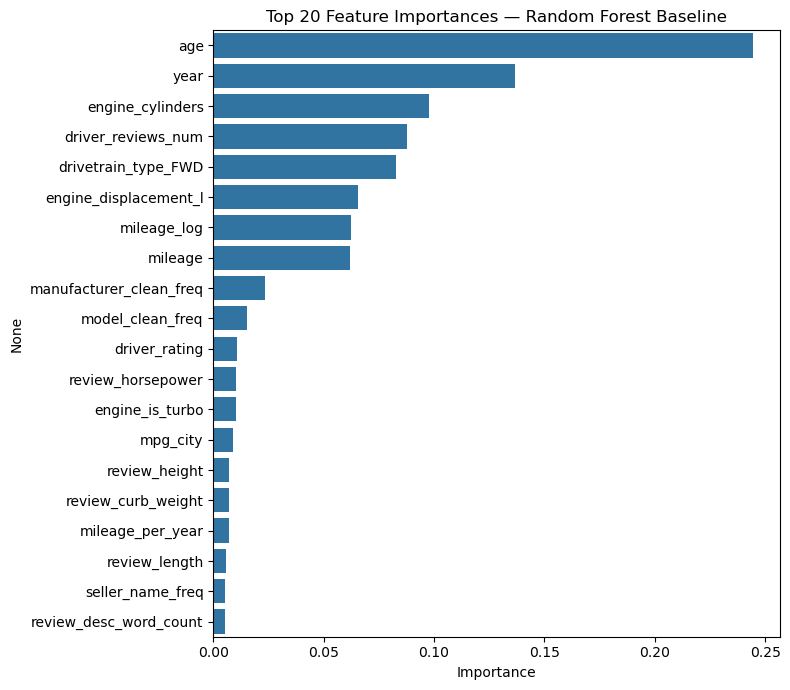

In [13]:
# Feature importance — where is the Random Forest actually getting signal from?
importances = pd.Series(rf_model.feature_importances_, index=X_train_final.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
sns.barplot(x=top20.values, y=top20.index)
plt.title('Top 20 Feature Importances — Random Forest Baseline')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## Part J — Does the review enrichment actually help?

Quick ablation: same Random Forest, features with vs. without the `review_*` / `has_review_match`
columns. This is the direct question 03_Post_EDA flagged as open — review features are
a "bonus feature set, not a hard dependency" since only ~53.5% of rows have them.

In [14]:
review_cols_final = [c for c in X_train_final.columns if c.startswith('review_') or c.startswith('has_review_match')]
non_review_cols = [c for c in X_train_final.columns if c not in review_cols_final]

print(f"Review-derived columns in final feature set: {len(review_cols_final)}")

rf_no_reviews = evaluate("Random Forest (no review features)", RandomForestRegressor(
    n_estimators=200, max_depth=18, n_jobs=-1, random_state=RANDOM_STATE),
    X_train_final[non_review_cols], y_train, X_test_final[non_review_cols], y_test)


Review-derived columns in final feature set: 13
--- Random Forest (no review features) ---
  R^2 (log-price):        0.944
  RMSE (log-price):       0.136
  MAE  (log-price):       0.088
  RMSE (dollars):         $6,481
  MAE  (dollars):         $2,689


## Summary

- Enriched listings with nearest-year expert-review features where `matched_review_model` exists (~53.5% of rows); `has_review_match` flags the rest so the model can use the absence itself as information.
- Engineered: `mileage_per_year`, log-mileage, split/averaged `mpg`, engine displacement/cylinders/turbo/hybrid flags from free-text `engine`, and missingness indicators for the sparse fields identified in 03_Post_EDA (`price_drop`, `seller_rating`, `driver_rating`, `mpg`, and the accident/ownership flags).
- Train/test split happens **before** frequency encoding and top-category grouping, so `manufacturer_clean`, `model_clean`, `seller_name`, and color encodings are fit on train only — no leakage into the test metrics above.
- Saved `cars_features_train.csv` / `cars_features_test.csv` (fully numeric, model-ready) and the fitted `ColumnTransformer` as `preprocessing_pipeline.joblib`, so the same preprocessing can be reused for the Deal-Quality Scorer module or a future inference API without redoing this notebook.
- Baseline Random Forest vs. Linear Regression gives a first read on achievable accuracy; the review-feature ablation in Part J tells you whether pulling in the Edmunds data is worth the join complexity for this specific target.

**Next steps:**
- If Part J shows review features meaningfully help: worth improving the join (e.g. weighting by how close the matched year actually was, since a 10-year-off match is noisier signal than a 1-year-off one).
- Hyperparameter tuning + cross-validation on the Random Forest (or try gradient boosting — XGBoost/LightGBM) before treating any of these numbers as final.
- The same `cars_features_*` files and pipeline are reusable as the starting point for the Deal-Quality Scorer module (predicted price vs. listed price = deal quality).
